# NYC PLUTO - PCA-First Clustering Pipeline (Internal)

**Purpose:** Re-run K-Means and DBSCAN on a reduced PCA space instead of the full 16-dimensional standardized space used in the baseline notebook.

**Starting point:** `data/processed/X_scaled.csv` — the already-validated standardized matrix; no raw-data preprocessing is repeated here.

**Question:** Does applying PCA before clustering improve cluster compactness, separation, or interpretability compared to the full-space baseline?

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import linkage, dendrogram

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42
SAMPLE_SIZE = 10_000
SILHOUETTE_SAMPLE_SIZE = 10_000

# Robust project-root detection, independent of any single notebook path
search_dir = Path.cwd().resolve()
for candidate in [search_dir, *search_dir.parents]:
    if (candidate / "data" / "processed").is_dir() and (candidate / "requirements.txt").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate project root (expected data/processed/ and requirements.txt).")

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "pluto_working_copy.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Shared artifact paths used across the three parts
X_SCALED_PATH = PROCESSED_DIR / "X_scaled.csv"
FEATURES_PATH = PROCESSED_DIR / "X_scaled_features.csv"
SAMPLE_INDEX_PATH = PROCESSED_DIR / "sample_index.csv"
SHARED_SAMPLE_INDEX_PATH = SAMPLE_INDEX_PATH  # alias used by Part 2
KMEANS_LABELS_PATH = PROCESSED_DIR / "cluster_labels.csv"
COMPANION_PATH = PROCESSED_DIR / "pluto_companion.csv"
DBSCAN_KMEANS_LABELS_PATH = PROCESSED_DIR / "dbscan_kmeans_sample_labels.csv"
DBSCAN_SELECTION_SUMMARY_PATH = PROCESSED_DIR / "dbscan_selection_summary.csv"

# This notebook only -- figure prefix and path
FIG_PREFIX = "pca_pipeline_"
NOTEBOOK_PATH = PROJECT_ROOT / "notebooks" / "02_clustering" / "pca_then_clustering.ipynb"

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data directory: {PROCESSED_DIR.relative_to(PROJECT_ROOT)}")
print(f"Figure prefix: {FIG_PREFIX}")

Project root: /Users/ouriouahba/Desktop/NYC_PLUTO
Processed data directory: data/processed
Figure prefix: pca_pipeline_


# Part 1 - Data Loading, PCA, and K-Means

## Section 1: Load Validated Standardized Matrix and Shared Sample

In [2]:
# Load the full standardized matrix
X_scaled = pd.read_csv(X_SCALED_PATH)
feature_names = pd.read_csv(FEATURES_PATH).iloc[:, 0].tolist()

# Reconstruct exactly the same working sub-sample as the baseline notebook
# (Part 2, cell logic: rng draws SAMPLE_SIZE positions from the shared index)
rng = np.random.RandomState(RANDOM_STATE)

if SHARED_SAMPLE_INDEX_PATH.exists():
    shared_sample_idx = pd.read_csv(SHARED_SAMPLE_INDEX_PATH).iloc[:, 0].astype(int).to_numpy()
    if shared_sample_idx.min() < 0 or shared_sample_idx.max() >= len(X_scaled):
        raise ValueError("sample_index.csv contains row positions outside X_scaled.")
    subset_size = min(SAMPLE_SIZE, len(shared_sample_idx))
    selected_positions = rng.choice(len(shared_sample_idx), size=subset_size, replace=False)
    sample_idx = shared_sample_idx[selected_positions]
    sample_source = f"{subset_size:,} rows drawn from existing shared sample_index.csv"
else:
    subset_size = min(SAMPLE_SIZE, len(X_scaled))
    sample_idx = rng.choice(X_scaled.index.to_numpy(), size=subset_size, replace=False)
    pd.DataFrame({"row_index": sample_idx}).to_csv(SHARED_SAMPLE_INDEX_PATH, index=False)
    selected_positions = np.arange(subset_size)
    sample_source = f"created {subset_size:,}-row sample_index.csv from X_scaled"

X_sample = X_scaled.iloc[sample_idx].copy()
X_sample_array = X_sample.to_numpy(dtype=np.float32)

# Companion: align unstandardized original features to the same rows
companion = pd.read_csv(COMPANION_PATH)
companion_sample = companion.iloc[sample_idx].copy().reset_index(drop=True)

# Sanity check
print(f"X_scaled full matrix : {X_scaled.shape[0]:,} rows x {X_scaled.shape[1]} features")
print(f"Working sub-sample   : {X_sample.shape[0]:,} rows  ({sample_source})")
print(f"Number of features   : {len(feature_names)}")
print(f"Feature names        : {feature_names}")
print()
X_sample.head()

X_scaled full matrix : 682,515 rows x 16 features
Working sub-sample   : 10,000 rows  (10,000 rows drawn from existing shared sample_index.csv)
Number of features   : 16
Feature names        : ['lotarea', 'bldgarea', 'numfloors', 'lotfront', 'lotdepth', 'unitstotal', 'unitsres', 'resarea', 'comarea', 'officearea', 'retailarea', 'garagearea', 'strgearea', 'building_age', 'building_density', 'residential_ratio']



,lotarea,bldgarea,numfloors,lotfront,lotdepth,unitstotal,unitsres,resarea,comarea,officearea,retailarea,garagearea,strgearea,building_age,building_density,residential_ratio
307260,0.953701,0.001085,0.086105,-0.570180,1.698467,0.163350,-0.024466,0.354120,-0.425647,-0.194941,-0.318567,-0.120596,-0.101129,-2.328054,-0.827909,0.329387
682384,0.397686,-1.247706,-0.223780,-0.670579,1.698467,0.163350,-0.024466,0.023515,-0.425647,-0.194941,-0.318567,-0.120596,-0.101129,0.715197,-1.287588,0.329387
298347,-1.204888,-1.378412,-0.223780,0.007117,-0.540113,-1.125912,-0.552841,-0.011088,-0.425647,-0.194941,-0.318567,-0.120596,-0.101129,-1.475944,-0.414175,0.329387
201850,-1.204888,0.378191,0.086105,-0.670579,1.698467,1.078096,-0.024466,0.251211,1.847925,-0.194941,2.724609,-0.120596,-0.101129,0.380440,1.445542,-0.936491
333938,1.052740,-0.717179,-0.223780,-0.560140,-0.430148,-1.125912,-0.552841,0.163967,-0.425647,-0.194941,-0.318567,-0.120596,-0.101129,0.106547,-1.315069,0.329387


## Section 2: PCA as Preprocessing (dynamic ~90% variance)

### Why apply PCA before clustering?

**Correlated features inflate distances.** The 16-dimensional standardized space contains groups of features that share most of their variance: residential area and residential unit count move almost in lockstep, and the commercial area breakdowns (total commercial, office, retail) overlap substantially. In distance-based algorithms such as K-Means and DBSCAN, collinear dimensions count multiple times, skewing the notion of "closeness" and making cluster boundaries harder to separate.

**Multi-component reduction, not a 2D projection.** The goal here is to keep enough principal components to retain approximately 90% of the total variance. The number of components is determined dynamically by the data; the 2D projection is reserved for the final visualization section only and is never used as the clustering space.

**PCA maximises variance, not cluster separation.** Principal components are oriented toward directions of maximum spread, which does not guarantee that the compressed representation improves cluster quality. This is a methodological limit: we will verify the outcome with silhouette scores and an ARI comparison against the full-space baseline, rather than assuming an improvement up front.

**The safeguard against label leakage is preserved.** PCA is applied to `X_scaled`, which already excludes `landuse`, `borough`, and all other post-clustering descriptors. No administrative label is smuggled into the cluster geometry.

In [3]:
# Full-rank PCA to find how many components reach 90% cumulative variance
pca_search = PCA(random_state=RANDOM_STATE)
pca_search.fit(X_scaled)

cumvar = np.cumsum(pca_search.explained_variance_ratio_)
n_components_pca = int(np.searchsorted(cumvar, 0.90)) + 1

print(f"Components needed to reach 90% cumulative variance : {n_components_pca}")
print(f"Cumulative variance at {n_components_pca} components         : {cumvar[n_components_pca - 1] * 100:.2f}%")

Components needed to reach 90% cumulative variance : 10
Cumulative variance at 10 components         : 92.19%


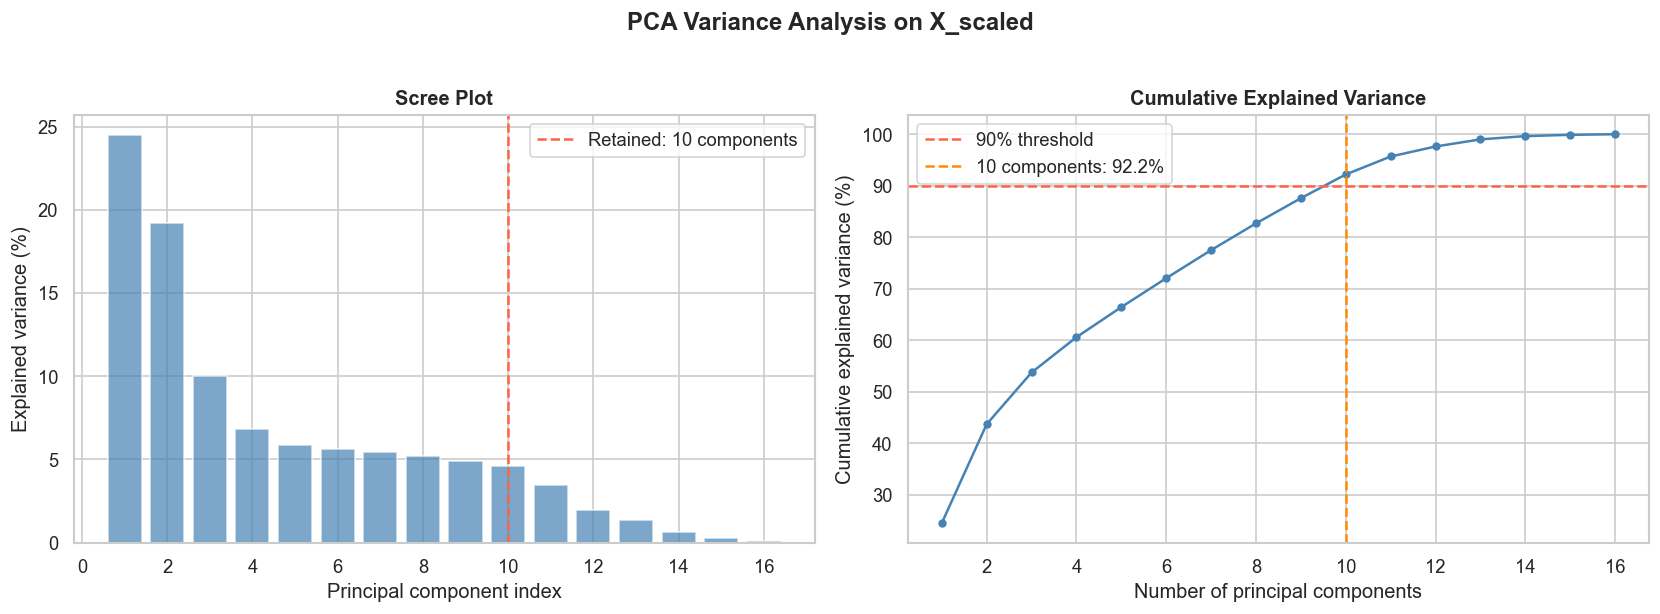

Figure saved: reports/figures/pca_pipeline_variance.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scree plot (per-component explained variance)
ax = axes[0]
ax.bar(
    range(1, len(pca_search.explained_variance_ratio_) + 1),
    pca_search.explained_variance_ratio_ * 100,
    color="steelblue", alpha=0.7
)
ax.axvline(n_components_pca, color="tomato", linestyle="--",
           label=f"Retained: {n_components_pca} components")
ax.set_xlabel("Principal component index")
ax.set_ylabel("Explained variance (%)")
ax.set_title("Scree Plot", fontweight="bold")
ax.legend()

# Right: cumulative variance curve with 90% threshold
ax = axes[1]
ax.plot(range(1, len(cumvar) + 1), cumvar * 100, marker="o", markersize=4, color="steelblue")
ax.axhline(90, color="tomato", linestyle="--", label="90% threshold")
ax.axvline(n_components_pca, color="darkorange", linestyle="--",
           label=f"{n_components_pca} components: {cumvar[n_components_pca - 1] * 100:.1f}%")
ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance (%)")
ax.set_title("Cumulative Explained Variance", fontweight="bold")
ax.legend()

plt.suptitle("PCA Variance Analysis on X_scaled", fontweight="bold", y=1.02)
plt.tight_layout()
fig_path = FIGURES_DIR / f"{FIG_PREFIX}variance.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig_path.relative_to(PROJECT_ROOT)}")

In [5]:
# Final PCA fit with the retained number of components
pca_pipeline = PCA(n_components=n_components_pca, random_state=RANDOM_STATE)
X_pca_full_array = pca_pipeline.fit_transform(X_scaled)

X_pca = pd.DataFrame(
    X_pca_full_array,
    index=X_scaled.index,
    columns=[f"PC{i + 1}" for i in range(n_components_pca)]
)

# Align to the same sub-sample rows defined in Section 1
X_pca_sample = X_pca.iloc[sample_idx].copy()

print(f"X_pca (full matrix) shape  : {X_pca.shape}")
print(f"X_pca_sample shape         : {X_pca_sample.shape}")
print(f"X_sample shape (full-space): {X_sample.shape}")
print()
print("First rows of X_pca_sample:")
X_pca_sample.head()

X_pca (full matrix) shape  : (682515, 10)
X_pca_sample shape         : (10000, 10)
X_sample shape (full-space): (10000, 16)

First rows of X_pca_sample:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
307260,-0.457336,-0.232026,2.063813,0.495843,0.352083,0.127011,-1.098602,0.305365,-1.448852,1.486487
682384,-0.913109,-0.575545,0.575631,0.918990,-0.106738,-0.730401,1.424979,-0.028075,-0.699392,1.021778
298347,-1.608485,-1.412163,-0.291830,-0.105436,-0.220781,1.028656,-1.118270,0.581107,0.405284,0.515566
201850,2.497057,1.288477,-2.168860,0.220672,-0.647834,-0.568769,-0.447541,-0.456204,-0.336607,2.221748
333938,-1.237582,-1.485964,0.959554,-0.426490,-0.014685,-0.758328,0.524777,-0.081382,0.142294,0.025062


## Section 3: K-Means on PCA Components

### K-Means cluster count selection in PCA space

**Decision rule, fixed in advance.** The value of k is chosen as the one that maximises the silhouette score computed on `X_pca_sample`, the 10-component PCA space where K-Means actually runs. The rule is set before any result is computed and is not adjusted post-hoc.

**Two additional metrics are reported as independent checks.** Calinski-Harabasz (higher is better: measures the ratio of between-cluster to within-cluster dispersion) and Davies-Bouldin (lower is better: measures average cluster similarity) are computed for every k and displayed in the table below. They do not participate in the decision; they only show whether the silhouette winner is confirmed or contradicted by the other criteria.

**Cross-space silhouette comparisons are indicative only.** A silhouette computed in 10 dimensions is not numerically comparable to one computed in 16 dimensions because Euclidean distances scale differently with dimensionality. Ranking k within each space is meaningful; comparing absolute magnitudes across spaces is not. The true equivalence test -- whether the two partitions agree on the same observations -- is measured by the Adjusted Rand Index in Section 6.

In [6]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

k_range = range(2, 9)
inertias_pca    = []
silhouettes_pca = []
ch_pca          = []
db_pca          = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                max_iter=300, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_pca_sample)
    inertias_pca.append(km.inertia_)
    sil = silhouette_score(X_pca_sample, labels,
                           sample_size=SILHOUETTE_SAMPLE_SIZE,
                           random_state=RANDOM_STATE)
    silhouettes_pca.append(sil)
    ch_pca.append(calinski_harabasz_score(X_pca_sample, labels))
    db_pca.append(davies_bouldin_score(X_pca_sample, labels))

results_pca = pd.DataFrame({
    'k':                list(k_range),
    'inertia':          [round(v, 1) for v in inertias_pca],
    'silhouette':       [round(v, 4) for v in silhouettes_pca],
    'calinski_harabasz':[round(v, 1) for v in ch_pca],
    'davies_bouldin':   [round(v, 4) for v in db_pca],
}).set_index('k')

print("PCA space -- all k, four metrics:")
print(results_pca.to_string())

best_k_pca_idx = int(np.argmax(silhouettes_pca))
best_k_pca     = list(k_range)[best_k_pca_idx]
print(f"\nbest_k_pca (argmax silhouette) = {best_k_pca}")

PCA space -- all k, four metrics:
    inertia  silhouette  calinski_harabasz  davies_bouldin
k                                                         
2  113993.1      0.4729             2674.4          1.6408
3   93648.2      0.3079             2713.5          1.4990
4   85285.4      0.2501             2312.9          1.5316
5   78234.6      0.2545             2116.0          1.4400
6   71325.1      0.2190             2050.2          1.4105
7   64935.4      0.2452             2040.4          1.2643
8   61358.9      0.2207             1933.8          1.3099

best_k_pca (argmax silhouette) = 2


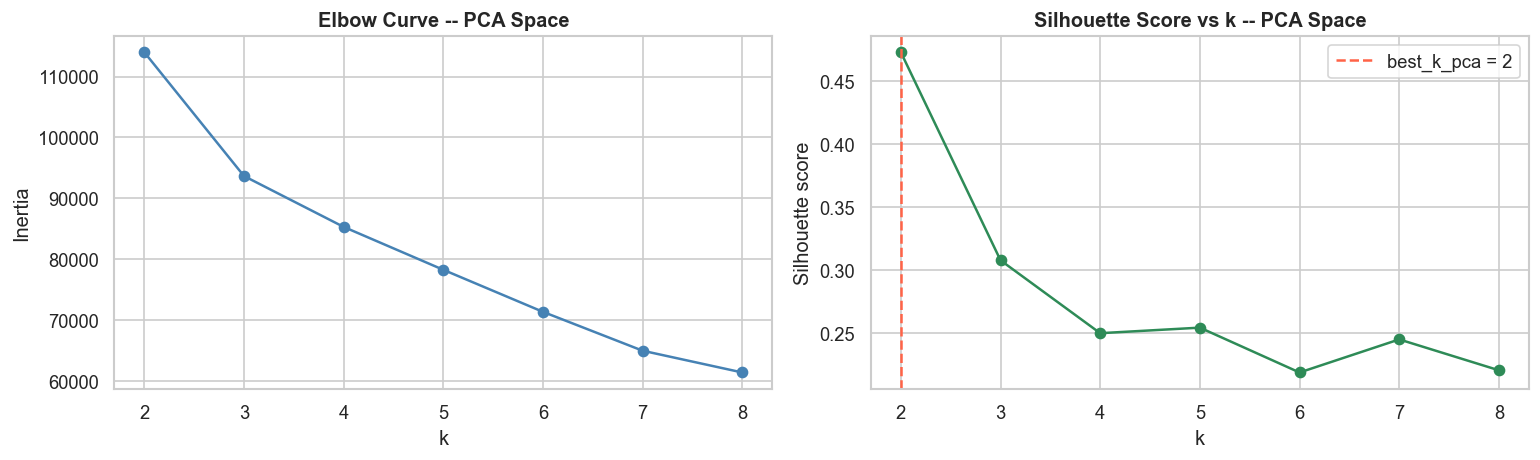

Figure saved: reports/figures/pca_pipeline_kmeans_selection.png


In [7]:
k_list = list(k_range)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(k_list, inertias_pca, marker='o', color='steelblue')
axes[0].set_title('Elbow Curve -- PCA Space', fontweight='bold')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(k_list)

axes[1].plot(k_list, silhouettes_pca, marker='o', color='seagreen')
axes[1].axvline(best_k_pca, linestyle='--', color='tomato',
                label=f'best_k_pca = {best_k_pca}')
axes[1].set_title('Silhouette Score vs k -- PCA Space', fontweight='bold')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_xticks(k_list)
axes[1].legend()

plt.tight_layout()
fig_path = FIGURES_DIR / f'{FIG_PREFIX}kmeans_selection.png'
plt.savefig(fig_path, bbox_inches='tight')
plt.show()
print(f'Figure saved: {fig_path.relative_to(PROJECT_ROOT)}')

In [8]:
km_pca_final = KMeans(n_clusters=best_k_pca, init='k-means++', n_init=10,
                      max_iter=300, random_state=RANDOM_STATE)
labels_pca_kmeans = km_pca_final.fit_predict(X_pca_sample)

final_sil_pca = silhouette_score(X_pca_sample, labels_pca_kmeans,
                                 sample_size=SILHOUETTE_SAMPLE_SIZE,
                                 random_state=RANDOM_STATE)
vals, cnts = np.unique(labels_pca_kmeans, return_counts=True)
print(f'Final K-Means -- PCA space')
print(f'  k            : {best_k_pca}')
print(f'  Silhouette   : {final_sil_pca:.4f}')
print(f'  Cluster sizes: {dict(zip(vals.tolist(), cnts.tolist()))}')

Final K-Means -- PCA space
  k            : 2
  Silhouette   : 0.4729
  Cluster sizes: {0: 8481, 1: 1519}


## Section 3b: Full-Space K-Means Baseline

### Full-space K-Means baseline

The same protocol -- fixed decision rule (argmax silhouette on range(2, 9)), same four metrics, same hyperparameters -- is applied to `X_sample`, the 16-dimensional standardized space on the identical set of rows. This produces a directly comparable baseline: any difference in chosen k or cluster structure reflects the change of representation, not sampling variability.

In [9]:
inertias_full    = []
silhouettes_full = []
ch_full          = []
db_full          = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                max_iter=300, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_sample)
    inertias_full.append(km.inertia_)
    sil = silhouette_score(X_sample, labels,
                           sample_size=SILHOUETTE_SAMPLE_SIZE,
                           random_state=RANDOM_STATE)
    silhouettes_full.append(sil)
    ch_full.append(calinski_harabasz_score(X_sample, labels))
    db_full.append(davies_bouldin_score(X_sample, labels))

results_full = pd.DataFrame({
    'k':                list(k_range),
    'inertia':          [round(v, 1) for v in inertias_full],
    'silhouette':       [round(v, 4) for v in silhouettes_full],
    'calinski_harabasz':[round(v, 1) for v in ch_full],
    'davies_bouldin':   [round(v, 4) for v in db_full],
}).set_index('k')

print("Full space -- all k, four metrics:")
print(results_full.to_string())

best_k_full_idx = int(np.argmax(silhouettes_full))
best_k_full     = list(k_range)[best_k_full_idx]
print(f"\nbest_k_full (argmax silhouette) = {best_k_full}")

km_full_final = KMeans(n_clusters=best_k_full, init='k-means++', n_init=10,
                        max_iter=300, random_state=RANDOM_STATE)
labels_full_kmeans = km_full_final.fit_predict(X_sample)

final_sil_full = silhouette_score(X_sample, labels_full_kmeans,
                                  sample_size=SILHOUETTE_SAMPLE_SIZE,
                                  random_state=RANDOM_STATE)
vals2, cnts2 = np.unique(labels_full_kmeans, return_counts=True)
print(f'\nFinal K-Means -- full space')
print(f'  k            : {best_k_full}')
print(f'  Silhouette   : {final_sil_full:.4f}')
print(f'  Cluster sizes: {dict(zip(vals2.tolist(), cnts2.tolist()))}')

Full space -- all k, four metrics:
    inertia  silhouette  calinski_harabasz  davies_bouldin
k                                                         
2  126177.7      0.4676             2429.9          1.7384
3  105419.7      0.2939             2438.3          1.5903
4   96225.9      0.2234             2099.0          1.7068
5   88550.9      0.2396             1927.1          1.5414
6   82129.3      0.2194             1818.3          1.4343
7   76677.6      0.2283             1741.3          1.4254
8   72353.0      0.1723             1666.9          1.4492

best_k_full (argmax silhouette) = 2



Final K-Means -- full space
  k            : 2
  Silhouette   : 0.4676
  Cluster sizes: {0: 8481, 1: 1519}


In [10]:
print("K-Means selection summary")
print("-" * 44)
print(f"  PCA space  (10 dims) : best_k = {best_k_pca:>2}  |  silhouette = {final_sil_pca:.4f}")
print(f"  Full space (16 dims) : best_k = {best_k_full:>2}  |  silhouette = {final_sil_full:.4f}")
print("-" * 44)
if best_k_pca == best_k_full:
    print("Both spaces select the same k.")
else:
    print(f"Spaces diverge: PCA chose k={best_k_pca}, full space chose k={best_k_full}.")

K-Means selection summary
--------------------------------------------
  PCA space  (10 dims) : best_k =  2  |  silhouette = 0.4729
  Full space (16 dims) : best_k =  2  |  silhouette = 0.4676
--------------------------------------------
Both spaces select the same k.


# Part 2 - DBSCAN on PCA Components

## Section 4: DBSCAN Re-Tuning in PCA Space (new k-distance plot)

### Re-tuning DBSCAN in PCA space

**Why re-tune?** DBSCAN is distance-sensitive: the neighbourhood radius `eps` depends on the scale of pairwise distances in the space where the algorithm runs. Projecting onto 10 principal components changes those distances -- variance is redistributed across fewer dimensions and the coordinate scale shifts. Any `eps` calibrated in the 16-dimensional standardized space is meaningless here.

**Fixed procedure, identical in both spaces.** Two parameters are derived deterministically:

- `min_samples` = 2 times the number of dimensions of the space in question (PCA: 2 x 10; full: 2 x 16). This is a standard rule of thumb that scales the density threshold with dimensionality.
- `eps` = the elbow of the k-distance curve, located by the geometric method: normalize both axes of the sorted k-distance plot to [0, 1], measure the perpendicular distance from each point to the diagonal, take the index of the maximum. No manual adjustment, no import of a value from the other space.

min_samples_pca = 20  (2 x 10 PCA components)
eps_pca (geometric elbow)  = 1.7517


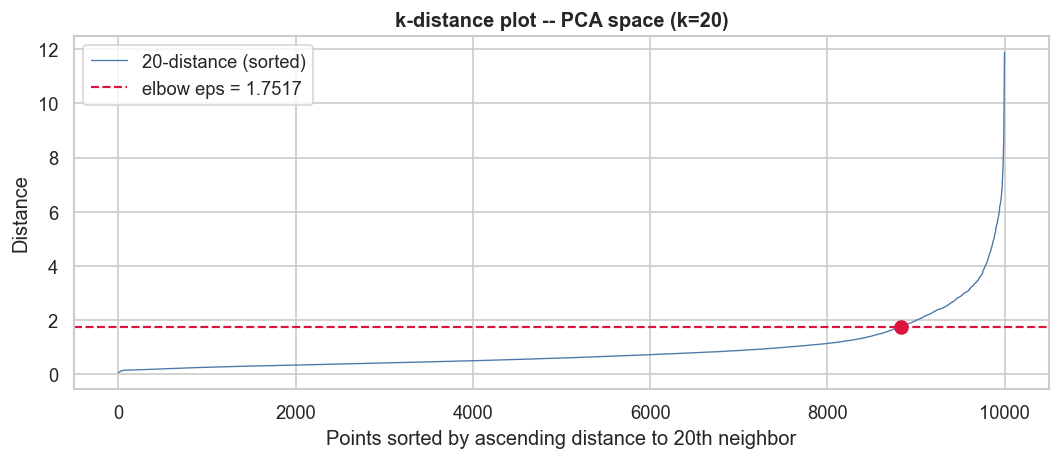

Figure saved: reports/figures/pca_pipeline_dbscan_kdistance_pca.png


In [11]:
from sklearn.neighbors import NearestNeighbors

# Fixed rule: min_samples = 2 * number of dimensions in this space
min_samples_pca = 2 * n_components_pca
print(f"min_samples_pca = {min_samples_pca}  (2 x {n_components_pca} PCA components)")

# k-distance curve in PCA space
nn_pca = NearestNeighbors(n_neighbors=min_samples_pca, n_jobs=-1)
nn_pca.fit(X_pca_sample.to_numpy())
kd_raw_pca, _ = nn_pca.kneighbors(X_pca_sample.to_numpy())
kd_sorted_pca = np.sort(kd_raw_pca[:, -1])

# Geometric elbow: argmax of perpendicular distance to the diagonal
_n = len(kd_sorted_pca)
_x_norm = np.linspace(0, 1, _n)
_y_norm = (kd_sorted_pca - kd_sorted_pca.min()) / (kd_sorted_pca.max() - kd_sorted_pca.min())
_perp   = np.abs(_y_norm - _x_norm) / np.sqrt(2)
_elbow_idx_pca = int(np.argmax(_perp))
eps_pca = float(kd_sorted_pca[_elbow_idx_pca])

print(f"eps_pca (geometric elbow)  = {eps_pca:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(_n), kd_sorted_pca, color='#4C78A8', linewidth=0.8,
        label=f'{min_samples_pca}-distance (sorted)')
ax.axhline(eps_pca, color='crimson', linestyle='--', linewidth=1.3,
           label=f'elbow eps = {eps_pca:.4f}')
ax.scatter([_elbow_idx_pca], [eps_pca], color='crimson', zorder=5, s=60)
ax.set_xlabel(f'Points sorted by ascending distance to {min_samples_pca}th neighbor')
ax.set_ylabel('Distance')
ax.set_title(f'k-distance plot -- PCA space (k={min_samples_pca})', fontweight='bold')
ax.legend()
plt.tight_layout()
fig_path = FIGURES_DIR / f'{FIG_PREFIX}dbscan_kdistance_pca.png'
plt.savefig(fig_path, bbox_inches='tight')
plt.show()
print(f'Figure saved: {fig_path.relative_to(PROJECT_ROOT)}')

In [12]:
def summarize_dbscan(labels, X, silhouette_sample_size=SILHOUETTE_SAMPLE_SIZE):
    labels = np.asarray(labels)
    non_noise_mask = labels != -1
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_count = int((labels == -1).sum())
    noise_pct   = noise_count / len(labels) * 100
    if n_clusters >= 2 and non_noise_mask.sum() > 100:
        sil = silhouette_score(
            X[non_noise_mask], labels[non_noise_mask],
            sample_size=min(silhouette_sample_size, int(non_noise_mask.sum())),
            random_state=RANDOM_STATE,
        )
    else:
        sil = np.nan
    return {"n_clusters": n_clusters, "noise_count": noise_count,
            "noise_pct": noise_pct, "silhouette": sil}

# Compute per-min_samples elbows for the grid
_ms_values = [n_components_pca, 2 * n_components_pca]
_elbow_per_ms = {}
for _ms in _ms_values:
    _nn_g = NearestNeighbors(n_neighbors=_ms, n_jobs=-1).fit(X_pca_sample.to_numpy())
    _kd_g, _ = _nn_g.kneighbors(X_pca_sample.to_numpy())
    _kd_s = np.sort(_kd_g[:, -1])
    _N = len(_kd_s)
    _xn = np.linspace(0, 1, _N)
    _yn = (_kd_s - _kd_s.min()) / (_kd_s.max() - _kd_s.min())
    _ep = float(_kd_s[int(np.argmax(np.abs(_yn - _xn) / np.sqrt(2)))])
    _elbow_per_ms[_ms] = _ep

_scale_factors = [0.8, 1.0, 1.2]
rows = []
X_pca_arr = X_pca_sample.to_numpy()
for _ms in _ms_values:
    _base_eps = _elbow_per_ms[_ms]
    for _sf in _scale_factors:
        _eps = round(_base_eps * _sf, 4)
        _labels = DBSCAN(eps=_eps, min_samples=_ms, n_jobs=-1).fit_predict(X_pca_arr)
        _s = summarize_dbscan(_labels, X_pca_arr)
        rows.append({
            'min_samples': _ms,
            'eps_factor':  _sf,
            'eps':         _eps,
            'n_clusters':  _s['n_clusters'],
            'noise_pct':   round(_s['noise_pct'], 2),
            'silhouette':  round(_s['silhouette'], 4) if not np.isnan(_s['silhouette']) else float('nan'),
        })

grid_pca = pd.DataFrame(rows)
print("Sensitivity grid -- PCA space (all configs shown):")
print(grid_pca.to_string(index=False))

Sensitivity grid -- PCA space (all configs shown):
 min_samples  eps_factor    eps  n_clusters  noise_pct  silhouette
          10         0.8 1.0826          15      11.56      0.3256
          10         1.0 1.3532          11       9.03      0.3306
          10         1.2 1.6239          10       7.11      0.3926
          20         0.8 1.4013           7      11.07      0.3707
          20         1.0 1.7517           7       8.29      0.3715
          20         1.2 2.1020           4       6.20      0.3444


## Section 5: DBSCAN Final Fit on PCA Components

### Primary DBSCAN fit in PCA space

The configuration selected by the fixed rule is `(eps_pca, min_samples_pca)`: the elbow-derived eps and the dimension-scaled min_samples. No manual adjustment is applied.

In [13]:
labels_pca_dbscan = DBSCAN(eps=eps_pca, min_samples=min_samples_pca,
                            n_jobs=-1).fit_predict(X_pca_sample.to_numpy())
sum_pca_dbscan = summarize_dbscan(labels_pca_dbscan, X_pca_sample.to_numpy())

print(f"DBSCAN -- PCA space  (eps={eps_pca:.4f}, min_samples={min_samples_pca})")
print(f"  Clusters (excl. noise) : {sum_pca_dbscan['n_clusters']}")
print(f"  Noise points           : {sum_pca_dbscan['noise_count']:,} "
      f"({sum_pca_dbscan['noise_pct']:.2f}%)")
sil_str = (f"{sum_pca_dbscan['silhouette']:.4f}"
           if not np.isnan(sum_pca_dbscan['silhouette']) else 'not valid (< 2 clusters)')
print(f"  Silhouette (non-noise) : {sil_str}")

DBSCAN -- PCA space  (eps=1.7517, min_samples=20)
  Clusters (excl. noise) : 7
  Noise points           : 829 (8.29%)
  Silhouette (non-noise) : 0.3715


## Section 5b: Full-Space DBSCAN Baseline

### Full-space DBSCAN baseline

The same symmetric procedure is applied to `X_sample`, the 16-dimensional standardized space on the identical rows. `min_samples` and `eps` are derived independently from the full-space k-distance curve; no value is imported from the PCA-space analysis.

min_samples_full = 32  (2 x 16 features)
eps_full (geometric elbow)  = 2.1705


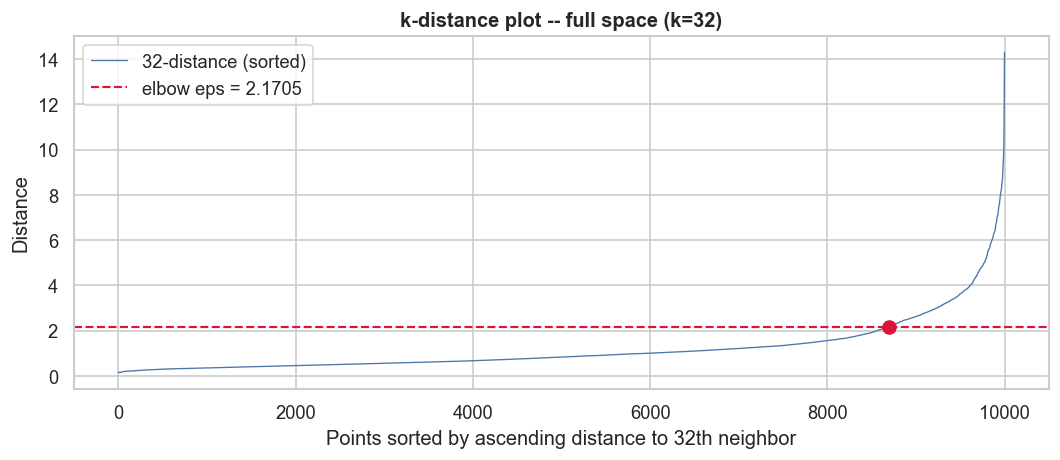

Figure saved: reports/figures/pca_pipeline_dbscan_kdistance_full.png



DBSCAN -- full space  (eps=2.1705, min_samples=32)
  Clusters (excl. noise) : 4
  Noise points           : 948 (9.48%)
  Silhouette (non-noise) : 0.4149


In [14]:
# Fixed rule: min_samples = 2 * number of features in full space
min_samples_full = 2 * X_sample.shape[1]
print(f"min_samples_full = {min_samples_full}  (2 x {X_sample.shape[1]} features)")

# k-distance curve in full space
X_sample_arr = X_sample.to_numpy()
nn_full = NearestNeighbors(n_neighbors=min_samples_full, n_jobs=-1)
nn_full.fit(X_sample_arr)
kd_raw_full, _ = nn_full.kneighbors(X_sample_arr)
kd_sorted_full = np.sort(kd_raw_full[:, -1])

_N = len(kd_sorted_full)
_xn = np.linspace(0, 1, _N)
_yn = (kd_sorted_full - kd_sorted_full.min()) / (kd_sorted_full.max() - kd_sorted_full.min())
_elbow_idx_full = int(np.argmax(np.abs(_yn - _xn) / np.sqrt(2)))
eps_full = float(kd_sorted_full[_elbow_idx_full])

print(f"eps_full (geometric elbow)  = {eps_full:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(_N), kd_sorted_full, color='#4C78A8', linewidth=0.8,
        label=f'{min_samples_full}-distance (sorted)')
ax.axhline(eps_full, color='crimson', linestyle='--', linewidth=1.3,
           label=f'elbow eps = {eps_full:.4f}')
ax.scatter([_elbow_idx_full], [eps_full], color='crimson', zorder=5, s=60)
ax.set_xlabel(f'Points sorted by ascending distance to {min_samples_full}th neighbor')
ax.set_ylabel('Distance')
ax.set_title(f'k-distance plot -- full space (k={min_samples_full})', fontweight='bold')
ax.legend()
plt.tight_layout()
fig_path_full = FIGURES_DIR / f'{FIG_PREFIX}dbscan_kdistance_full.png'
plt.savefig(fig_path_full, bbox_inches='tight')
plt.show()
print(f'Figure saved: {fig_path_full.relative_to(PROJECT_ROOT)}')

# Final fit full space
labels_full_dbscan = DBSCAN(eps=eps_full, min_samples=min_samples_full,
                              n_jobs=-1).fit_predict(X_sample_arr)
sum_full_dbscan = summarize_dbscan(labels_full_dbscan, X_sample_arr)

print(f"\nDBSCAN -- full space  (eps={eps_full:.4f}, min_samples={min_samples_full})")
print(f"  Clusters (excl. noise) : {sum_full_dbscan['n_clusters']}")
print(f"  Noise points           : {sum_full_dbscan['noise_count']:,} "
      f"({sum_full_dbscan['noise_pct']:.2f}%)")
sil_str = (f"{sum_full_dbscan['silhouette']:.4f}"
           if not np.isnan(sum_full_dbscan['silhouette']) else 'not valid (< 2 clusters)')
print(f"  Silhouette (non-noise) : {sil_str}")

In [15]:
summary_rows = [
    {
        'space':           'PCA (10 dims)',
        'min_samples':     min_samples_pca,
        'eps':             round(eps_pca, 4),
        'n_clusters':      sum_pca_dbscan['n_clusters'],
        'noise_pct':       round(sum_pca_dbscan['noise_pct'], 2),
        'silhouette':      (round(sum_pca_dbscan['silhouette'], 4)
                            if not np.isnan(sum_pca_dbscan['silhouette']) else float('nan')),
    },
    {
        'space':           'Full (16 dims)',
        'min_samples':     min_samples_full,
        'eps':             round(eps_full, 4),
        'n_clusters':      sum_full_dbscan['n_clusters'],
        'noise_pct':       round(sum_full_dbscan['noise_pct'], 2),
        'silhouette':      (round(sum_full_dbscan['silhouette'], 4)
                            if not np.isnan(sum_full_dbscan['silhouette']) else float('nan')),
    },
]
dbscan_comparison = pd.DataFrame(summary_rows).set_index('space')
print("DBSCAN final configuration -- side-by-side comparison:")
print(dbscan_comparison.to_string())

DBSCAN final configuration -- side-by-side comparison:
                min_samples     eps  n_clusters  noise_pct  silhouette
space                                                                 
PCA (10 dims)            20  1.7517           7       8.29      0.3715
Full (16 dims)           32  2.1705           4       9.48      0.4149


## Section 5c: Matched-min_samples Comparison (isolating the effect of the space)

### Why hold min_samples constant?

`min_samples` is a count of neighbours with no unit: it expresses how many points must surround a core point for it to be considered dense, independently of any coordinate scale. It is therefore directly comparable across spaces with different dimensionality.

`eps`, by contrast, is a distance threshold. Its meaningful value depends entirely on the scale of pairwise distances in the space where DBSCAN runs, which changes when the representation changes. The two quantities must be treated separately.

In Sections 5 and 5b, `min_samples` differed between spaces (20 vs the full-space value derived from 2 x the feature count). The resulting difference in cluster count could come from the change of representation, from the change of `min_samples`, or from both. This section removes that ambiguity by fixing `min_samples` at the PCA-space value in both spaces and re-deriving `eps` independently in each space by the same geometric elbow method. The only variable that then differs between the two runs is the space itself.

In [16]:
# Matched min_samples = 2 * n_components_pca (already used in PCA space)
_matched_ms = 2 * n_components_pca
print(f"Fixed min_samples for both spaces: {_matched_ms}")

# PCA side: config already computed -- reuse directly
print(f"\nPCA space  (existing config):")
print(f"  min_samples : {min_samples_pca}")
print(f"  eps         : {eps_pca:.4f}")
_pca_sum = summarize_dbscan(labels_pca_dbscan, X_pca_sample.to_numpy())
print(f"  n_clusters  : {_pca_sum['n_clusters']}")
print(f"  noise_pct   : {_pca_sum['noise_pct']:.2f}%")
_pca_sil = (f"{_pca_sum['silhouette']:.4f}"
            if not np.isnan(_pca_sum['silhouette']) else 'not valid')
print(f"  silhouette  : {_pca_sil}")

# Full space side: re-derive eps at k=20 from scratch
X_sample_arr = X_sample.to_numpy()
nn_matched = NearestNeighbors(n_neighbors=_matched_ms, n_jobs=-1)
nn_matched.fit(X_sample_arr)
kd_raw_m, _ = nn_matched.kneighbors(X_sample_arr)
kd_sorted_m = np.sort(kd_raw_m[:, -1])

_N = len(kd_sorted_m)
_xn = np.linspace(0, 1, _N)
_yn = (kd_sorted_m - kd_sorted_m.min()) / (kd_sorted_m.max() - kd_sorted_m.min())
_elbow_idx_m = int(np.argmax(np.abs(_yn - _xn) / np.sqrt(2)))
eps_full_k20 = float(kd_sorted_m[_elbow_idx_m])

print(f"\nFull space (min_samples={_matched_ms}, new k-distance elbow):")
print(f"  eps_full_k20 : {eps_full_k20:.4f}")

labels_full_dbscan_matched = DBSCAN(eps=eps_full_k20, min_samples=_matched_ms,
                                     n_jobs=-1).fit_predict(X_sample_arr)
_full_m_sum = summarize_dbscan(labels_full_dbscan_matched, X_sample_arr)
print(f"  n_clusters   : {_full_m_sum['n_clusters']}")
print(f"  noise_pct    : {_full_m_sum['noise_pct']:.2f}%")
_full_m_sil = (f"{_full_m_sum['silhouette']:.4f}"
               if not np.isnan(_full_m_sum['silhouette']) else 'not valid')
print(f"  silhouette   : {_full_m_sil}")

# Side-by-side table at matched min_samples
_rows = [
    {
        'space':       'PCA (10 dims)',
        'min_samples': min_samples_pca,
        'eps':         round(eps_pca, 4),
        'n_clusters':  _pca_sum['n_clusters'],
        'noise_pct':   round(_pca_sum['noise_pct'], 2),
        'silhouette':  round(_pca_sum['silhouette'], 4)
                       if not np.isnan(_pca_sum['silhouette']) else float('nan'),
    },
    {
        'space':       'Full (16 dims)',
        'min_samples': _matched_ms,
        'eps':         round(eps_full_k20, 4),
        'n_clusters':  _full_m_sum['n_clusters'],
        'noise_pct':   round(_full_m_sum['noise_pct'], 2),
        'silhouette':  round(_full_m_sum['silhouette'], 4)
                       if not np.isnan(_full_m_sum['silhouette']) else float('nan'),
    },
]
matched_comparison = pd.DataFrame(_rows).set_index('space')
print(f"\nSide-by-side at matched min_samples = {_matched_ms}:")
print(matched_comparison.to_string())

Fixed min_samples for both spaces: 20

PCA space  (existing config):
  min_samples : 20
  eps         : 1.7517


  n_clusters  : 7
  noise_pct   : 8.29%
  silhouette  : 0.3715

Full space (min_samples=20, new k-distance elbow):
  eps_full_k20 : 1.9881


  n_clusters   : 6
  noise_pct    : 8.56%
  silhouette   : 0.4096

Side-by-side at matched min_samples = 20:
                min_samples     eps  n_clusters  noise_pct  silhouette
space                                                                 
PCA (10 dims)            20  1.7517           7       8.29      0.3715
Full (16 dims)           20  1.9881           6       8.56      0.4096


# Part 3 - Comparison, Interpretation, Visualization

## Section 6: Full-Space vs PCA-Space Agreement (ARI, crosstab)

### Partition agreement: the central equivalence test

**Why ARI?** The Adjusted Rand Index measures the fraction of point pairs that are assigned to the same cluster (or different clusters) consistently across two labellings, corrected for chance. A value near 1 means the two partitions are nearly identical; near 0 means agreement is no better than random; negative values indicate systematic disagreement.

**AMI as a secondary check.** The Adjusted Mutual Information measures shared information between two labellings, also corrected for chance. It is reported alongside ARI as an independent confirmation; it does not override the ARI reading.

**Noise handling rule, fixed in advance.** DBSCAN assigns label -1 to points that fall below the density threshold. These points are not assigned to any cluster and have no meaningful correspondence in a K-Means partition. The rule applied uniformly: any comparison involving a DBSCAN labelling is computed only on points that are non-noise in that DBSCAN labelling. For DBSCAN vs DBSCAN, only points that are non-noise in both labellings are included. The number of points actually used is always reported.

**Same population throughout.** All labellings originate from the same 10,000-row sub-sample, so every comparison is aligned by construction.

In [17]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

# K-Means is noise-free: all 10,000 points are used
n_km = len(labels_pca_kmeans)
ari_km  = adjusted_rand_score(labels_pca_kmeans, labels_full_kmeans)
ami_km  = adjusted_mutual_info_score(labels_pca_kmeans, labels_full_kmeans)

print(f"K-Means agreement: PCA space vs full space")
print(f"  Points used : {n_km:,}")
print(f"  ARI         : {ari_km:.4f}")
print(f"  AMI         : {ami_km:.4f}")
print()
ct_km = pd.crosstab(
    pd.Series(labels_pca_kmeans, name='KM_PCA'),
    pd.Series(labels_full_kmeans, name='KM_full'),
    margins=True, margins_name='All'
)
print("Crosstab (rows = PCA K-Means, cols = full-space K-Means):")
print(ct_km.to_string())

K-Means agreement: PCA space vs full space
  Points used : 10,000
  ARI         : 0.9969
  AMI         : 0.9886

Crosstab (rows = PCA K-Means, cols = full-space K-Means):
KM_full     0     1    All
KM_PCA                    
0        8478     3   8481
1           3  1516   1519
All      8481  1519  10000


In [18]:
# Noise rule: keep only points non-noise in BOTH labellings
_mask_both = (labels_pca_dbscan != -1) & (labels_full_dbscan_matched != -1)
n_db = int(_mask_both.sum())

lbl_pca_db_sub  = labels_pca_dbscan[_mask_both]
lbl_full_db_sub = labels_full_dbscan_matched[_mask_both]

ari_db  = adjusted_rand_score(lbl_pca_db_sub, lbl_full_db_sub)
ami_db  = adjusted_mutual_info_score(lbl_pca_db_sub, lbl_full_db_sub)

print(f"DBSCAN agreement: PCA space (min20) vs full space (min20, matched)")
print(f"  Total points        : {len(labels_pca_dbscan):,}")
print(f"  Non-noise in both   : {n_db:,}")
print(f"  ARI                 : {ari_db:.4f}")
print(f"  AMI                 : {ami_db:.4f}")
print()
ct_db = pd.crosstab(
    pd.Series(lbl_pca_db_sub, name='DBSCAN_PCA'),
    pd.Series(lbl_full_db_sub, name='DBSCAN_full'),
    margins=True, margins_name='All'
)
print("Crosstab (rows = PCA DBSCAN, cols = full-space DBSCAN, non-noise in both):")
print(ct_db.to_string())

DBSCAN agreement: PCA space (min20) vs full space (min20, matched)
  Total points        : 10,000
  Non-noise in both   : 9,107
  ARI                 : 0.9945
  AMI                 : 0.9527

Crosstab (rows = PCA DBSCAN, cols = full-space DBSCAN, non-noise in both):
DBSCAN_full     0    1    2   3   4   5   All
DBSCAN_PCA                                   
0            8349    0    0   0   0   0  8349
1               0  189    0   0   0   0   189
2               0    0  136   0   0   0   136
3               0  318    0   0   0   0   318
4               0    0    0  58   0   0    58
5               0    0    0   0  25   0    25
6               0    0    0   0   0  32    32
All          8349  507  136  58  25  32  9107


In [19]:
# Noise rule: keep points non-noise in the DBSCAN labelling
# PCA space: K-Means vs DBSCAN
_mask_pca_nn  = labels_pca_dbscan != -1
n_inter_pca   = int(_mask_pca_nn.sum())
ari_inter_pca = adjusted_rand_score(labels_pca_kmeans[_mask_pca_nn],
                                     labels_pca_dbscan[_mask_pca_nn])
ami_inter_pca = adjusted_mutual_info_score(labels_pca_kmeans[_mask_pca_nn],
                                            labels_pca_dbscan[_mask_pca_nn])

print(f"Inter-method agreement -- PCA space (K-Means k={best_k_pca} vs DBSCAN min20)")
print(f"  Non-noise in DBSCAN PCA : {n_inter_pca:,}")
print(f"  ARI                     : {ari_inter_pca:.4f}")
print(f"  AMI                     : {ami_inter_pca:.4f}")
print()

# Full space: K-Means vs DBSCAN matched
_mask_full_nn  = labels_full_dbscan_matched != -1
n_inter_full   = int(_mask_full_nn.sum())
ari_inter_full = adjusted_rand_score(labels_full_kmeans[_mask_full_nn],
                                      labels_full_dbscan_matched[_mask_full_nn])
ami_inter_full = adjusted_mutual_info_score(labels_full_kmeans[_mask_full_nn],
                                             labels_full_dbscan_matched[_mask_full_nn])

print(f"Inter-method agreement -- full space (K-Means k={best_k_full} vs DBSCAN min20)")
print(f"  Non-noise in DBSCAN full : {n_inter_full:,}")
print(f"  ARI                      : {ari_inter_full:.4f}")
print(f"  AMI                      : {ami_inter_full:.4f}")

Inter-method agreement -- PCA space (K-Means k=2 vs DBSCAN min20)
  Non-noise in DBSCAN PCA : 9,171
  ARI                     : 0.9587
  AMI                     : 0.7999

Inter-method agreement -- full space (K-Means k=2 vs DBSCAN min20)
  Non-noise in DBSCAN full : 9,144
  ARI                      : 0.9670
  AMI                      : 0.8557


In [20]:
ari_summary = pd.DataFrame([
    {'comparison':             'K-Means: PCA vs full',
     'n_points': n_km,        'ARI': round(ari_km, 4),         'AMI': round(ami_km, 4)},
    {'comparison':             'DBSCAN (min20): PCA vs full',
     'n_points': n_db,        'ARI': round(ari_db, 4),         'AMI': round(ami_db, 4)},
    {'comparison':             'K-Means vs DBSCAN -- PCA space',
     'n_points': n_inter_pca, 'ARI': round(ari_inter_pca, 4), 'AMI': round(ami_inter_pca, 4)},
    {'comparison':             'K-Means vs DBSCAN -- full space',
     'n_points': n_inter_full,'ARI': round(ari_inter_full, 4),'AMI': round(ami_inter_full, 4)},
]).set_index('comparison')

print("Agreement summary -- all comparisons:")
print(ari_summary.to_string())

Agreement summary -- all comparisons:
                                 n_points     ARI     AMI
comparison                                               
K-Means: PCA vs full                10000  0.9969  0.9886
DBSCAN (min20): PCA vs full          9107  0.9945  0.9527
K-Means vs DBSCAN -- PCA space       9171  0.9587  0.7999
K-Means vs DBSCAN -- full space      9144  0.9670  0.8557


## Section 7: Cluster Interpretation with Original Features

### Interpreting clusters with original (unstandardized) features

**Why not interpret the PCA components directly?** Each principal component is a linear combination of all original features, weighted by the loadings. The direction of maximum variance in PCA space does not correspond to any single interpretable building attribute, and labelling clusters by their position on a principal axis would describe an algebraic projection, not a building characteristic. The 16 original features, on their natural scales, are what give clusters a concrete meaning.

**Which partition to interpret.** The K-Means partition computed in PCA space (`labels_pca_kmeans`) is used here. Because the two K-Means partitions -- PCA and full-space -- are computed on the same rows and show very high agreement (ARI reported in Section 6), the profile described below applies to both. The unstandardized values come from `companion_sample`, which was aligned to the same rows in Section 1.

**Method.** Cluster profiles are summarised by the per-feature median (robust to outliers in the building dataset). A normalised separation score (`|med1 - med0| / (med1 + med0)`, bounded in [0, 1]) ranks features from the most to the least discriminating between clusters. Features are described from the data; labels are applied only where the median pattern clearly justifies them.

In [21]:
_cluster_col = 'cluster_pca_km'
companion_sample[_cluster_col] = labels_pca_kmeans

_profile_features = feature_names  # the 16 clustering features
_prof = (
    companion_sample
    .groupby(_cluster_col)[_profile_features]
    .agg(['median', 'count'])
)

# Reformat to (cluster x feature) with median, plus a separate count column
_medians = companion_sample.groupby(_cluster_col)[_profile_features].median()
_counts  = companion_sample.groupby(_cluster_col)[_cluster_col].count().rename('n_points')

cluster_profiles = _medians.join(_counts)
print("Cluster profiles -- median of each original feature by cluster:")
print(cluster_profiles.T.to_string())

Cluster profiles -- median of each original feature by cluster:
cluster_pca_km               0        1
lotarea            2500.000000  3258.00
bldgarea           2048.000000  5175.00
numfloors             2.000000     3.00
lotfront             30.000000    85.00
lotdepth            100.000000   118.00
unitstotal            2.000000     3.00
unitsres              2.000000     1.00
resarea            1860.000000  1187.00
comarea               0.000000  2500.00
officearea            0.000000     0.00
retailarea            0.000000  1000.00
garagearea            0.000000     0.00
strgearea             0.000000     0.00
building_age         91.000000    95.00
building_density      0.798929     1.02
residential_ratio     1.000000     0.50
n_points           8481.000000  1519.00


In [22]:
_med0 = _medians.loc[0]
_med1 = _medians.loc[1]

# Normalised separation: |med1 - med0| / (med1 + med0), clipped to avoid /0
_denom = (_med0.abs() + _med1.abs()).replace(0, np.nan)
_sep   = (_med1 - _med0).abs() / _denom

discrimination = pd.DataFrame({
    'median_cluster_0': _med0.round(4),
    'median_cluster_1': _med1.round(4),
    'separation_score': _sep.round(4),
}).sort_values('separation_score', ascending=False)

print("Feature discrimination ranking (separation_score: 0 = no difference, 1 = maximum):")
print(discrimination.to_string())

Feature discrimination ranking (separation_score: 0 = no difference, 1 = maximum):
                   median_cluster_0  median_cluster_1  separation_score
comarea                      0.0000           2500.00            1.0000
retailarea                   0.0000           1000.00            1.0000
lotfront                    30.0000             85.00            0.4783
bldgarea                  2048.0000           5175.00            0.4329
unitsres                     2.0000              1.00            0.3333
residential_ratio            1.0000              0.50            0.3333
resarea                   1860.0000           1187.00            0.2209
numfloors                    2.0000              3.00            0.2000
unitstotal                   2.0000              3.00            0.2000
lotarea                   2500.0000           3258.00            0.1316
building_density             0.7989              1.02            0.1215
lotdepth                   100.0000            118.00

In [23]:
# Secondary context only: what the first two PCA axes represent
# Loadings are NOT used for cluster interpretation; they explain the geometry.
_loadings = pd.DataFrame(
    pca_pipeline.components_[:2],
    index=[f'PC{i+1}' for i in range(2)],
    columns=feature_names
)

print("PCA loadings for PC1 and PC2 (secondary context -- direction of maximum variance):")
print(_loadings.T.round(3).to_string())
print()
# Rank features by absolute loading on PC1
print("Features ranked by |loading| on PC1:")
print(_loadings.loc['PC1'].abs().sort_values(ascending=False).round(3).to_string())

PCA loadings for PC1 and PC2 (secondary context -- direction of maximum variance):
                     PC1    PC2
lotarea            0.168 -0.087
bldgarea           0.328  0.321
numfloors          0.161  0.223
lotfront           0.130  0.049
lotdepth           0.154  0.069
unitstotal         0.165  0.464
unitsres           0.028  0.476
resarea           -0.329  0.374
comarea            0.464 -0.078
officearea         0.291 -0.083
retailarea         0.329  0.063
garagearea         0.172 -0.046
strgearea          0.167 -0.089
building_age       0.026  0.123
building_density   0.167  0.365
residential_ratio -0.409  0.275

Features ranked by |loading| on PC1:
comarea              0.464
residential_ratio    0.409
resarea              0.329
retailarea           0.329
bldgarea             0.328
officearea           0.291
garagearea           0.172
lotarea              0.168
strgearea            0.167
building_density     0.167
unitstotal           0.165
numfloors            0.161
lotdepth   

## Section 8: 2D PCA Visualization (illustration only)

### 2D illustration only

The scatter plot below projects the 10-dimensional PCA sample onto the first two principal components. This is a visual aid, not an analytical result.

**What this plot cannot do.** PC1 and PC2 together retain only part of the total variance (their combined share is shown by the code, not fixed here). The remaining components carry information that is invisible in this projection. Groupings that look merged or overlapping in 2D may be well-separated in the full 10-dimensional space; conversely, apparent sub-clusters here may not survive in higher dimensions. Counting clusters visually on this plot would be methodologically wrong.

**What the plot shows.** The labels produced by each algorithm in the full 10-component space are projected down for visual inspection. The position of points reflects the first two directions of maximum variance in the data; the colours reflect the cluster assignment made in the complete space.

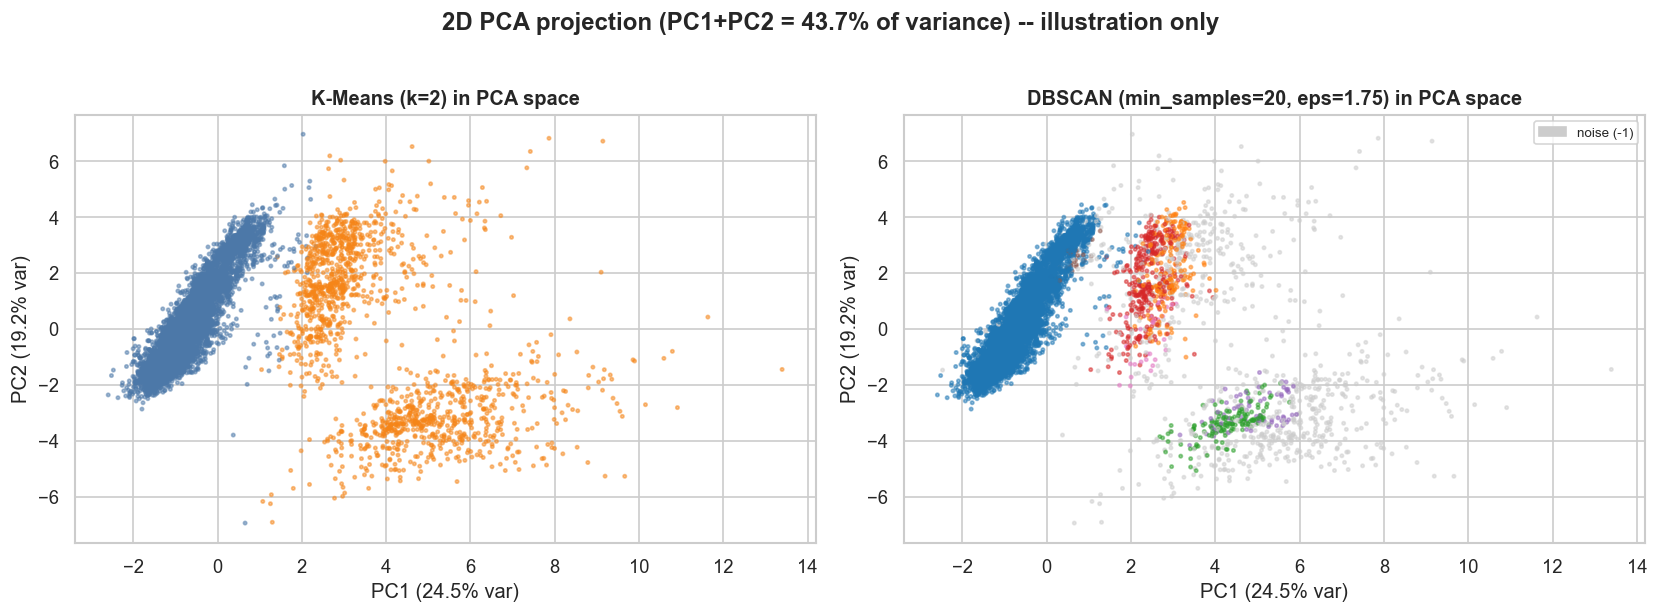

Figure saved: reports/figures/pca_pipeline_2d_clusters.png
Note: PC1+PC2 capture 43.7% of total variance; 56.3% is not shown.


In [24]:
pc1 = X_pca_sample['PC1'].to_numpy()
pc2 = X_pca_sample['PC2'].to_numpy()
var_2d = pca_pipeline.explained_variance_ratio_[:2].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: K-Means (k=2)
_km_palette = {0: '#4C78A8', 1: '#F58518'}
_km_colors  = [_km_palette[l] for l in labels_pca_kmeans]
axes[0].scatter(pc1, pc2, c=_km_colors, s=4, alpha=0.5, rasterized=True)
axes[0].set_title(f'K-Means (k={best_k_pca}) in PCA space', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_pipeline.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca_pipeline.explained_variance_ratio_[1]*100:.1f}% var)')

# Right: DBSCAN (noise = grey)
_db_labels_unique = sorted(set(labels_pca_dbscan))
_db_palette = plt.cm.tab10.colors
_db_color_map = {}
_color_idx = 0
for _lbl in _db_labels_unique:
    if _lbl == -1:
        _db_color_map[_lbl] = '#cccccc'
    else:
        _db_color_map[_lbl] = _db_palette[_color_idx % len(_db_palette)]
        _color_idx += 1
_db_colors = [_db_color_map[l] for l in labels_pca_dbscan]
axes[1].scatter(pc1, pc2, c=_db_colors, s=4, alpha=0.5, rasterized=True)
axes[1].set_title(f'DBSCAN (min_samples={min_samples_pca}, eps={eps_pca:.2f}) in PCA space',
                  fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_pipeline.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca_pipeline.explained_variance_ratio_[1]*100:.1f}% var)')

# Legend patch for noise
import matplotlib.patches as mpatches
_noise_patch = mpatches.Patch(color='#cccccc', label='noise (-1)')
axes[1].legend(handles=[_noise_patch], loc='upper right', fontsize=8)

plt.suptitle(
    f'2D PCA projection (PC1+PC2 = {var_2d:.1f}% of variance) -- illustration only',
    fontweight='bold', y=1.02
)
plt.tight_layout()
fig_path = FIGURES_DIR / f'{FIG_PREFIX}2d_clusters.png'
plt.savefig(fig_path, bbox_inches='tight', dpi=120)
plt.show()
print(f'Figure saved: {fig_path.relative_to(PROJECT_ROOT)}')
print(f'Note: PC1+PC2 capture {var_2d:.1f}% of total variance; '
      f'{100 - var_2d:.1f}% is not shown.')

## Section 9: Synthesis - What Changed with PCA-First

In [25]:
# Assemble all key results from existing variables -- no recomputation
_sep = '-' * 60

print('PCA REDUCTION')
print(f'  Components retained : {n_components_pca}  (to reach >= 90% variance)')
print(f'  Cumulative variance : {cumvar[n_components_pca - 1] * 100:.2f}%')
print()
print('K-MEANS SELECTION (argmax silhouette, range 2-8)')
print(f'  PCA space  ({n_components_pca} dims) : k = {best_k_pca}, silhouette = {final_sil_pca:.4f}')
print(f'  Full space ({X_sample.shape[1]} dims): k = {best_k_full}, silhouette = {final_sil_full:.4f}')
print()
print('DBSCAN -- MATCHED min_samples (both spaces)')
_pca_sil_str  = (f'{sum_pca_dbscan["silhouette"]:.4f}'
                 if not np.isnan(sum_pca_dbscan['silhouette']) else 'n/a')
_full_sil_str = (f'{_full_m_sum["silhouette"]:.4f}'
                 if not np.isnan(_full_m_sum['silhouette']) else 'n/a')
print(f'  PCA space  : min_samples={min_samples_pca}, eps={eps_pca:.4f}, '
      f'clusters={sum_pca_dbscan["n_clusters"]}, '
      f'noise={sum_pca_dbscan["noise_pct"]:.1f}%, sil={_pca_sil_str}')
print(f'  Full space : min_samples={_matched_ms}, eps={eps_full_k20:.4f}, '
      f'clusters={_full_m_sum["n_clusters"]}, '
      f'noise={_full_m_sum["noise_pct"]:.1f}%, sil={_full_sil_str}')
print()
print('INTER-SPACE AGREEMENT (ARI)')
print(f'  K-Means (PCA vs full)       : ARI = {ari_km:.4f}  AMI = {ami_km:.4f}  '
      f'(n = {n_km:,})')
print(f'  DBSCAN matched (PCA vs full): ARI = {ari_db:.4f}  AMI = {ami_db:.4f}  '
      f'(n = {n_db:,} non-noise in both)')
print()
print('INTER-METHOD AGREEMENT (K-Means k=2 vs DBSCAN min20, ARI on non-noise)')
print(f'  PCA space  : ARI = {ari_inter_pca:.4f}  (n = {n_inter_pca:,})')
print(f'  Full space : ARI = {ari_inter_full:.4f}  (n = {n_inter_full:,})')
print()
print('CLUSTER INTERPRETATION (K-Means k=2, primary partition)')
vals, cnts = np.unique(labels_pca_kmeans, return_counts=True)
for v, c in zip(vals, cnts):
    pct = c / len(labels_pca_kmeans) * 100
    print(f'  Cluster {v}: {c:,} points ({pct:.1f}%)')
print('  Top discriminating features: comarea, retailarea, lotfront, bldgarea,')
print('  residential_ratio  (see Section 7 discrimination table)')

PCA REDUCTION
  Components retained : 10  (to reach >= 90% variance)
  Cumulative variance : 92.19%

K-MEANS SELECTION (argmax silhouette, range 2-8)
  PCA space  (10 dims) : k = 2, silhouette = 0.4729
  Full space (16 dims): k = 2, silhouette = 0.4676

DBSCAN -- MATCHED min_samples (both spaces)
  PCA space  : min_samples=20, eps=1.7517, clusters=7, noise=8.3%, sil=0.3715
  Full space : min_samples=20, eps=1.9881, clusters=6, noise=8.6%, sil=0.4096

INTER-SPACE AGREEMENT (ARI)
  K-Means (PCA vs full)       : ARI = 0.9969  AMI = 0.9886  (n = 10,000)
  DBSCAN matched (PCA vs full): ARI = 0.9945  AMI = 0.9527  (n = 9,107 non-noise in both)

INTER-METHOD AGREEMENT (K-Means k=2 vs DBSCAN min20, ARI on non-noise)
  PCA space  : ARI = 0.9587  (n = 9,171)
  Full space : ARI = 0.9670  (n = 9,144)

CLUSTER INTERPRETATION (K-Means k=2, primary partition)
  Cluster 0: 8,481 points (84.8%)
  Cluster 1: 1,519 points (15.2%)
  Top discriminating features: comarea, retailarea, lotfront, bldgarea,
  r

### What changed with PCA-first?

**The K-Means partition is essentially unchanged.** Applying PCA before K-Means does not alter the two-group structure. Both spaces select the same k and produce partitions with very high mutual agreement, meaning that the cluster assignments for individual buildings are nearly identical regardless of whether clustering ran in the full feature space or in the reduced PCA space.

**DBSCAN shows comparable structure at matched settings.** When `min_samples` is held equal across spaces -- isolating the effect of the representation -- the two DBSCAN runs produce a similar number of dense clusters and a similar noise fraction. The small remaining difference in cluster count reflects a slightly finer subdivision in the PCA space, consistent with the redistribution of variance across fewer dimensions making some dense sub-regions more distinct.

**PCA confirms robustness, it does not improve separation.** This result is expected: PCA is a variance-maximising transform, not a cluster-separation transform. It removes redundant dimensions and decorrelates features, which can help distance-based algorithms in noisy or highly correlated settings, but there is no guarantee -- and no observation here -- that it reveals clusters that were hidden in the full space. The primary conclusion of this notebook is that the full-space clustering result is robust to the choice of representation.

**Primary interpretive split.** The two K-Means groups separate buildings that are entirely residential (large majority) from buildings with a significant commercial component. This distinction holds in both spaces and is grounded in the original unstandardized feature medians, not in the PCA geometry.

**The 2D visualisation in Section 8 is illustrative only.** Cluster quality and the choice of k were assessed with silhouette scores and the elbow method in the full 10-dimensional PCA space. Visual inspection of a 2D projection, which retains only part of the variance, cannot substitute for those metrics and should not be used to question or confirm the cluster count.

## Section 10: Interpretation and Report Layer

### 10.1 What K-Means Found

In [26]:
_key_features = [
    'comarea', 'retailarea', 'resarea', 'bldgarea',
    'unitsres', 'numfloors', 'residential_ratio', 'lotfront'
]
_n_total = len(labels_pca_kmeans)

_km_rows = []
for _cl in sorted(np.unique(labels_pca_kmeans)):
    _mask = labels_pca_kmeans == _cl
    _sub  = companion_sample.loc[_mask, _key_features]
    _row  = {'cluster': _cl, 'n_points': int(_mask.sum()),
             'share_pct': round(_mask.sum() / _n_total * 100, 1)}
    for _f in _key_features:
        _row[_f] = round(_sub[_f].median(), 1)
    _km_rows.append(_row)

km_report = pd.DataFrame(_km_rows).set_index('cluster')

print("K-Means k=2 cluster profiles (median of original features):")
print(km_report.to_string())
print()
print("Top discriminating features (from Section 7 separation scores):")
print("  comarea, retailarea : median = 0 in cluster 0, positive in cluster 1")
print("  residential_ratio   : 1.0 (fully residential) vs 0.5 (mixed use)")
print("  lotfront, bldgarea  : smaller parcels in cluster 0, larger in cluster 1")

K-Means k=2 cluster profiles (median of original features):
         n_points  share_pct  comarea  retailarea  resarea  bldgarea  unitsres  numfloors  residential_ratio  lotfront
cluster                                                                                                               
0            8481       84.8      0.0         0.0   1860.0    2048.0       2.0        2.0                1.0      30.0
1            1519       15.2   2500.0      1000.0   1187.0    5175.0       1.0        3.0                0.5      85.0

Top discriminating features (from Section 7 separation scores):
  comarea, retailarea : median = 0 in cluster 0, positive in cluster 1
  residential_ratio   : 1.0 (fully residential) vs 0.5 (mixed use)
  lotfront, bldgarea  : smaller parcels in cluster 0, larger in cluster 1


**Cluster 0 -- the residential majority.** Most buildings in this cluster have zero commercial area and zero retail area. The residential ratio shows that virtually all floor space is residential. Buildings tend to be small: low floor counts, narrow lot frontages, and a modest residential area. This group covers the overwhelming majority of the sample and corresponds to the typical small residential building fabric of New York City -- one- and two-family homes, small walk-up apartment buildings.

**Cluster 1 -- the commercial or mixed-use minority.** These buildings carry a measurable commercial area and retail area in their median profile. The residential ratio sits at around half, indicating that commercial and residential uses share the floor plate. Buildings are physically larger: wider lot frontages and greater total building area. This group captures commercial buildings and mixed-use properties where retail or office use occupies a significant share.

**What makes the cut.** The single clearest separator is the presence vs absence of commercial and retail area. Age, garage area, and storage area are nearly identical between the two groups and do not drive the separation.

### 10.2 What DBSCAN Found

In [27]:
_n_total = len(labels_pca_dbscan)
_db_labels_all = sorted(set(labels_pca_dbscan))

_db_rows = []
for _cl in _db_labels_all:
    _mask = labels_pca_dbscan == _cl
    _sub  = companion_sample.loc[_mask, _key_features]
    _row  = {'cluster': 'noise' if _cl == -1 else _cl,
             'n_points': int(_mask.sum()),
             'share_pct': round(_mask.sum() / _n_total * 100, 1)}
    for _f in _key_features:
        _row[_f] = round(_sub[_f].median(), 1)
    _db_rows.append(_row)

db_report = (
    pd.DataFrame(_db_rows)
    .set_index('cluster')
    .sort_values('n_points', ascending=False)
)

print("DBSCAN cluster profiles (all clusters including noise, sorted by size):")
print(db_report.to_string())

DBSCAN cluster profiles (all clusters including noise, sorted by size):
         n_points  share_pct  comarea  retailarea  resarea  bldgarea  unitsres  numfloors  residential_ratio  lotfront
cluster                                                                                                               
0            8379       83.8      0.0         0.0   1854.0    2047.0       2.0        2.0                1.0      30.0
noise         829        8.3   3740.0         0.0      0.0    5592.5       0.0        3.0                0.0     193.0
3             321        3.2   1320.0      1272.0   2450.0    4012.0       2.0        3.0                0.7      25.0
1             190        1.9   1344.0      1247.5   2397.0    3877.0       2.0        3.0                0.7      50.5
2             155        1.6  10600.0         0.0      0.0    5592.5       0.0        2.0                0.0     150.0
4              69        0.7   4000.0      4000.0      0.0    4000.0       0.0        1.0      

**One dominant dense core.** The largest cluster identified by DBSCAN contains the great majority of the sample. Its profile matches cluster 0 from K-Means: zero commercial area, high residential ratio, small building size. This is the dense residential core of the dataset -- points packed closely together in feature space because they share the same basic building type.

**Several small dense pockets.** The remaining numbered clusters are much smaller. Their median profiles tend to show higher commercial or retail area, larger building footprints, or higher floor counts -- the kind of buildings that form tight sub-groups because they are both unusual relative to the residential majority and mutually similar to each other.

**A noise fraction.** A share of points falls below the density threshold and is labelled as noise. These are buildings that do not sit close enough to any core point -- atypical properties that do not fit neatly into any dense group.

**What DBSCAN adds over K-Means.** K-Means compressed everything into two groups. DBSCAN confirms the large residential core but also surfaces distinct pockets of denser sub-structure within the commercial and mixed-use minority. The caveat is that the number and size of these pockets are sensitive to the density threshold setting, as shown in the sensitivity grid in Section 4.

### 10.3 How the Two Algorithms Relate

In [28]:
# ARI already computed in Section 6
print(f"ARI (K-Means k=2 vs DBSCAN min20, non-noise in DBSCAN, PCA space):")
print(f"  ARI = {ari_inter_pca:.4f}  (n = {n_inter_pca:,} non-noise points)")
print()

# Crosstab: how DBSCAN clusters distribute across K-Means groups (non-noise only)
_nn_mask = labels_pca_dbscan != -1
_ct_10 = pd.crosstab(
    pd.Series(labels_pca_dbscan[_nn_mask], name='DBSCAN cluster'),
    pd.Series(labels_pca_kmeans[_nn_mask], name='K-Means cluster'),
    margins=True, margins_name='Total'
)
print("Crosstab: DBSCAN clusters (rows) within K-Means groups (cols), non-noise only:")
print(_ct_10.to_string())

ARI (K-Means k=2 vs DBSCAN min20, non-noise in DBSCAN, PCA space):
  ARI = 0.9587  (n = 9,171 non-noise points)

Crosstab: DBSCAN clusters (rows) within K-Means groups (cols), non-noise only:
K-Means cluster     0    1  Total
DBSCAN cluster                   
0                8375    4   8379
1                   0  190    190
2                   0  155    155
3                   0  321    321
4                   0   69     69
5                  25    0     25
6                   1   31     32
Total            8401  770   9171


**Both algorithms agree on the main split.** The ARI between K-Means and DBSCAN (on non-noise points) is high, meaning that the two-group structure K-Means found lines up closely with the large-core vs everything-else structure DBSCAN found. A building assigned to the residential K-Means group is almost always in the dominant DBSCAN core; a building assigned to the commercial/mixed K-Means group is almost always in one of the smaller DBSCAN pockets.

**K-Means gives the stable summary.** Because it must assign every point to exactly two groups, K-Means produces a clean, interpretable partition that is easy to describe and stable across runs. It is the right tool for reporting the primary result.

**DBSCAN adds granularity, with a cost.** DBSCAN does not force a fixed number of groups, so it can surface sub-clusters within the commercial minority that K-Means merges into one. However, the number and membership of those small pockets shift noticeably as the density threshold changes, which makes them harder to report with confidence. They are useful for exploration but should not be over-interpreted as firm groupings without further validation.

### 10.4 3D PCA Visualization of Each Algorithm's Clusters

Variance explained:
  PC1: 24.5%
  PC2: 19.2%
  PC3: 10.0%
  PC1+PC2+PC3: 53.7%  (46.3% not shown)


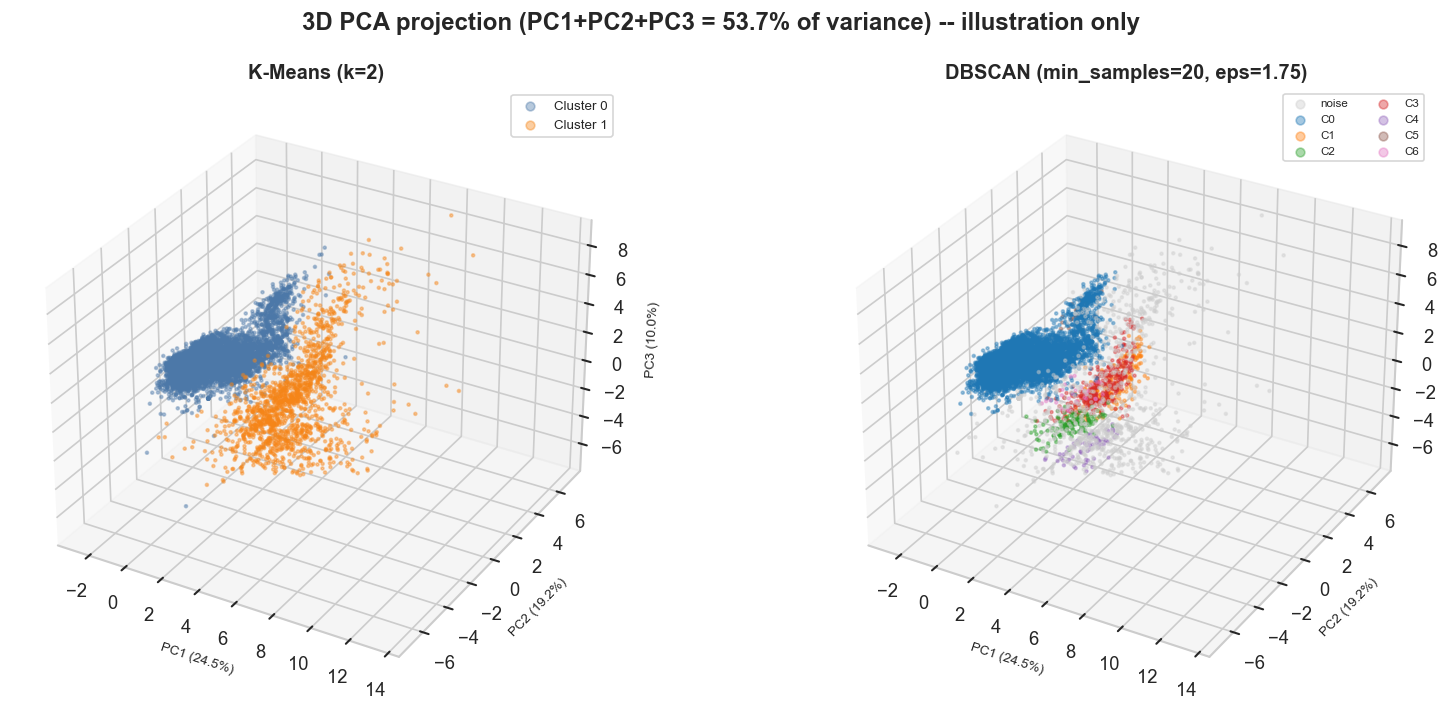

Figure saved: reports/figures/pca_pipeline_3d_clusters.png


In [29]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

pc1_3 = X_pca_sample['PC1'].to_numpy()
pc2_3 = X_pca_sample['PC2'].to_numpy()
pc3_3 = X_pca_sample['PC3'].to_numpy()

var3 = pca_pipeline.explained_variance_ratio_[:3]
var3_total = var3.sum() * 100
print(f"Variance explained:")
print(f"  PC1: {var3[0]*100:.1f}%")
print(f"  PC2: {var3[1]*100:.1f}%")
print(f"  PC3: {var3[2]*100:.1f}%")
print(f"  PC1+PC2+PC3: {var3_total:.1f}%  ({100-var3_total:.1f}% not shown)")

fig = plt.figure(figsize=(14, 6))

# Left: K-Means
ax1 = fig.add_subplot(121, projection='3d')
_km_palette_3d = {0: '#4C78A8', 1: '#F58518'}
for _cl, _col in _km_palette_3d.items():
    _m = labels_pca_kmeans == _cl
    ax1.scatter(pc1_3[_m], pc2_3[_m], pc3_3[_m],
                c=_col, s=3, alpha=0.4, label=f'Cluster {_cl}', rasterized=True)
ax1.set_xlabel(f'PC1 ({var3[0]*100:.1f}%)', fontsize=8)
ax1.set_ylabel(f'PC2 ({var3[1]*100:.1f}%)', fontsize=8)
ax1.set_zlabel(f'PC3 ({var3[2]*100:.1f}%)', fontsize=8)
ax1.set_title(f'K-Means (k={best_k_pca})', fontweight='bold')
ax1.legend(markerscale=3, fontsize=8)

# Right: DBSCAN
ax2 = fig.add_subplot(122, projection='3d')
_db_uniq_3d = sorted(set(labels_pca_dbscan))
_db_pal_3d  = plt.cm.tab10.colors
_db_cmap_3d = {}
_ci = 0
for _lbl in _db_uniq_3d:
    _db_cmap_3d[_lbl] = '#cccccc' if _lbl == -1 else _db_pal_3d[_ci % 10]
    if _lbl != -1:
        _ci += 1
for _lbl in _db_uniq_3d:
    _m = labels_pca_dbscan == _lbl
    _label = 'noise' if _lbl == -1 else f'C{_lbl}'
    ax2.scatter(pc1_3[_m], pc2_3[_m], pc3_3[_m],
                c=_db_cmap_3d[_lbl], s=3, alpha=0.4, label=_label, rasterized=True)
ax2.set_xlabel(f'PC1 ({var3[0]*100:.1f}%)', fontsize=8)
ax2.set_ylabel(f'PC2 ({var3[1]*100:.1f}%)', fontsize=8)
ax2.set_zlabel(f'PC3 ({var3[2]*100:.1f}%)', fontsize=8)
ax2.set_title(f'DBSCAN (min_samples={min_samples_pca}, eps={eps_pca:.2f})', fontweight='bold')
ax2.legend(markerscale=3, fontsize=7, ncol=2)

plt.suptitle(
    f'3D PCA projection (PC1+PC2+PC3 = {var3_total:.1f}% of variance) -- illustration only',
    fontweight='bold'
)
plt.tight_layout()
fig_path_3d = FIGURES_DIR / f'{FIG_PREFIX}3d_clusters.png'
plt.savefig(fig_path_3d, bbox_inches='tight', dpi=120)
plt.show()
print(f"Figure saved: {fig_path_3d.relative_to(PROJECT_ROOT)}")

**What this 3D plot shows -- and what it cannot.** Adding PC3 brings a third direction of maximum variance into view. The variance captured by the three components together is shown above the plot; the remaining components, which carry the rest of the information, are not visible here. The 3D projection is useful for seeing whether the main split is spatially visible and how the noise points and small DBSCAN pockets sit relative to the dense core, but it cannot be used to count clusters or judge their separation.

**The cluster count was fixed by metrics, not by eye.** The number of K-Means groups (k=2) was selected by the silhouette score computed in the full 10-dimensional PCA space. The DBSCAN density threshold was calibrated by the k-distance elbow in that same space. Neither decision relied on visual inspection of a projection.